# Phase 5 — Explainability, confidence intervals and the final report

Three jobs:

1. **Grad-CAM** — one heatmap *per biomarker*, not one generic saliency map. The question is
   whether the evidence for *intraretinal fluid* sits on plausible retinal structure, and a
   class-agnostic map cannot answer that.
2. **Patient-level bootstrap** — turn point estimates into intervals, and check whether any two
   models actually separate.
3. **The report** — assemble everything, and state plainly what the evidence does and does not
   support.

### What a heatmap is and is not

Grad-CAM shows *where the model looked*. It is not evidence that the model reasoned correctly,
and it is not causal. Its most reliable use is negative: if the mass sits on the image border,
on blank vitreous, or on burnt-in acquisition text, the model is exploiting an artefact and the
result is not trustworthy no matter how good the AUPRC looks. Section 3 checks that explicitly.

---
## 1. Setup

In [12]:
import os
import sys
import subprocess
import importlib
from pathlib import Path

REPO_ROOT = Path("/content/ClinBioGate")
PACKAGE_FILE = (
    REPO_ROOT
    / "src"
    / "olives_biomarkers"
    / "__init__.py"
)

# Restore the repository if Colab assigned a fresh machine.
if not PACKAGE_FILE.is_file():
    if REPO_ROOT.exists():
        raise RuntimeError(
            f"{REPO_ROOT} exists but is not a complete repository"
        )

    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/PasBless1/ClinBioGate.git",
            str(REPO_ROOT),
        ],
        check=True,
    )

os.chdir(REPO_ROOT)

SRC_DIR = str(REPO_ROOT / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

importlib.invalidate_caches()

import olives_biomarkers

print("Repository:", REPO_ROOT)
print("Package:", olives_biomarkers.__file__)

Repository: /content/ClinBioGate
Package: /content/ClinBioGate/src/olives_biomarkers/__init__.py


In [13]:
from olives_biomarkers import (
    ExperimentRunner,
    OlivesPipeline,
    ResultsAggregator,
    RunEvaluator,
    RunResult,
)

In [14]:
# Restore Phase 5 state after a Colab runtime restart.
from google.colab import drive
drive.mount('/content/drive')
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image

REPO_ROOT = Path('/content/ClinBioGate').resolve()
assert (REPO_ROOT / 'pyproject.toml').is_file(), 'Run the clone/bootstrap cell first.'
sys.path.insert(0, str(REPO_ROOT / 'src'))

from olives_biomarkers import ExperimentRunner, OlivesPipeline, ResultsAggregator, RunEvaluator, RunResult
from olives_biomarkers.config import ConfigLoader
from olives_biomarkers.evaluation import AttentionSanityChecker, GradCAM, MultiLabelMetrics, PatientBootstrap, ResultsPlotter
from olives_biomarkers.models import ModelFactory
from olives_biomarkers.training import CheckpointManager

assert torch.cuda.is_available(), 'Enable the A100 GPU in Colab.'
BUDGET = 'colab_gpu'
pipeline = OlivesPipeline.from_config(REPO_ROOT / 'configs' / 'data.yaml', repo_root=REPO_ROOT)
loader = ConfigLoader(REPO_ROOT)

DRIVE_ROOT = Path('/content/drive/MyDrive/olives')
RUNS_DIR = DRIVE_ROOT / 'outputs' / 'runs' / BUDGET
FIGURES = DRIVE_ROOT / 'outputs' / 'figures' / 'phase5'
FIGURES.mkdir(parents=True, exist_ok=True)

drive_cache = DRIVE_ROOT / 'data' / 'processed' / 'images_labelled'
repo_cache = REPO_ROOT / 'data' / 'processed' / 'images_labelled'
if drive_cache.exists() and not repo_cache.exists():
    repo_cache.parent.mkdir(parents=True, exist_ok=True)
    repo_cache.symlink_to(drive_cache, target_is_directory=True)

plotter = ResultsPlotter()
def show(figure, name):
    if figure is not None:
        plotter.save(figure, FIGURES / f'{name}.png')
        plt.show()

manifest = pipeline.get_manifest()
all_results = RunResult.load_all(RUNS_DIR)
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'completed runs loaded from {RUNS_DIR}: {len(all_results)}')
if not all_results:
    raise RuntimeError(f'No completed A100 runs found in {RUNS_DIR}; finish Phase 4 training first.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
20:13:11 | INFO    | olives.pipeline | loading cached manifest: /content/ClinBioGate/data/manifests/disease_classification_train.parquet
GPU: NVIDIA A100-SXM4-80GB
completed runs loaded from /content/drive/MyDrive/olives/outputs/runs/colab_gpu: 1


In [15]:
# Explanations need an image model; the clinical-only baseline has nothing to visualise.
image_runs = [r for r in all_results if r.model_name != "clinical_only"]
assert image_runs, "no image model found - run Phase 2 first"
result = max(image_runs, key=lambda r: r.test_metrics.get("macro_auprc", -1))
print(f"explaining: {result.run_id} ({result.model_name})")

config = loader.load(result.run_dir / "resolved_config.yaml")
runner = ExperimentRunner(pipeline, config, output_root=RUNS_DIR)
frame = pipeline.modelling_frame(manifest, attach_cache=True)
assignment = pipeline.make_holdout_split(manifest, write=False)
data = runner.build_data_module(frame, assignment, manifest.label_columns)

model = ModelFactory().build(
    config.model, n_labels=len(manifest.label_columns), clinical_dim=data.preprocessor.output_dim
)
CheckpointManager(result.run_dir / "checkpoints", run_id=result.run_id).load(
    model, map_location=pipeline.env.device
)
model.to(pipeline.env.device).eval()
print(f"restored {config.model.name}, Grad-CAM target layer: {type(model.feature_layer).__name__}")

explaining: oct_only_holdout_seed42_a100_20260828_190437 (oct_only)
20:13:13 | INFO    | olives.splits | holdout split 'holdout': train=52 val=13 test=13 calibration=9 patients
20:13:13 | INFO    | olives.preprocessing | ClinicalPreprocessor fitted on 5672 rows / 52 patients: {'bcva': 78.0, 'cst': 284.0}
20:13:13 | INFO    | olives.dataset | partition 'train': 5672 rows, 52 patients
20:13:13 | INFO    | olives.dataset | partition 'val': 1470 rows, 13 patients
20:13:13 | INFO    | olives.dataset | partition 'test': 1372 rows, 13 patients
20:13:13 | INFO    | olives.dataset | partition 'calibration': 882 rows, 9 patients
20:13:13 | INFO    | olives.callbacks | loaded checkpoint oct_only_holdout_seed42_a100_20260828_190437_best.pt (epoch 16)
restored oct_only, Grad-CAM target layer: Sequential


---
## 2. Grad-CAM per biomarker

In [16]:
test_dataset = data.datasets["test"]
label_names = manifest.label_columns
thresholds = result.thresholds.as_array()

def explain(index, labels=None):
    """Grad-CAM heatmaps for one test scan, plus the raw image for overlay."""
    item = test_dataset[index]
    image = item["image"].unsqueeze(0)
    clinical = item["clinical"].unsqueeze(0)
    targets = item["target"].numpy()
    chosen = labels or label_names

    with GradCAM(model, device=pipeline.env.device) as cam:
        results = [
            cam.generate(
                image, label_names.index(name), clinical=clinical,
                label_name=name, target=float(targets[label_names.index(name)]),
            )
            for name in chosen
        ]
    raw = np.asarray(test_dataset.load_image(index).convert("L"))
    return raw, results, item

# Pick a scan carrying several biomarkers, so the per-label maps can be compared.
counts = test_dataset.targets.sum(axis=1)
index = int(np.argsort(counts)[-1])
raw, cams, item = explain(index, labels=["irf", "drt_me", "irhrf", "favf", "pavf"])
print(f"scan {index}: patient {item['patient_id']}, "
      f"{int(counts[index])} biomarkers present")

scan 1002: patient 209, 8 biomarkers present


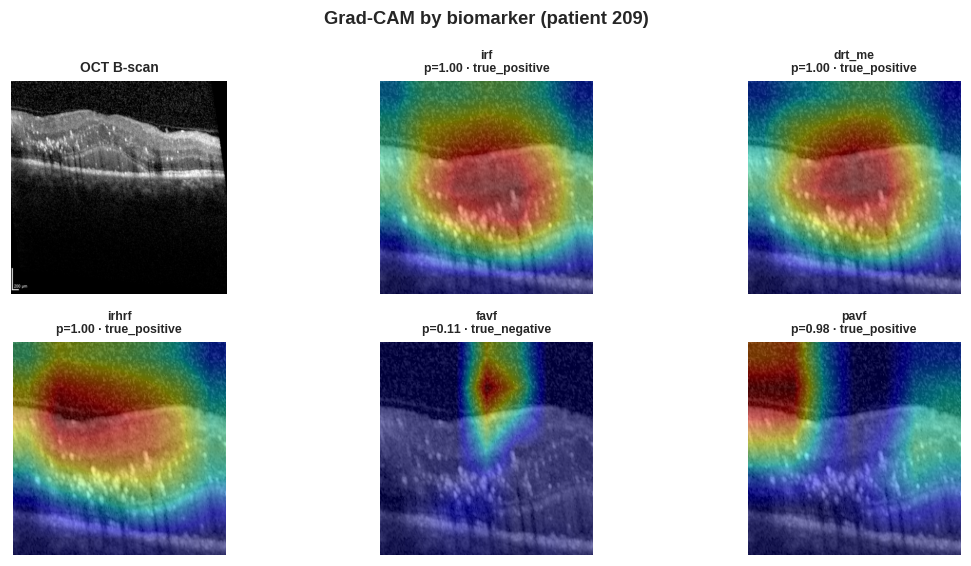

In [17]:
show(plotter.gradcam_overlay(raw, cams, n_cols=3,
                             title=f"Grad-CAM by biomarker (patient {item['patient_id']})"),
     "01_gradcam_per_label")

The panels should differ. If every biomarker produces the same heatmap, the model has learned one
generic "abnormality" detector and the multilabel head is just re-weighting it — which would
explain strong correlated labels and weak rare ones, and is worth knowing.

Look in particular at whether **IRF** and **DRT/ME** attend to the intraretinal cystic region,
and whether **PAVF/FAVF** attend to the vitreous boundary *above* the retina. Those are different
anatomical locations, so genuinely different maps are the encouraging outcome.

---
## 3. Attention sanity check

The negative use of explanations: is the model attending to anatomy, or to artefacts?

In [18]:
checker = AttentionSanityChecker(border_fraction=0.10, intensity_threshold=0.05)

rng = np.random.default_rng(0)
sample_indices = rng.choice(len(test_dataset), size=min(40, len(test_dataset)), replace=False)

rows = []
for scan_index in sample_indices:
    raw_i, cams_i, _ = explain(int(scan_index), labels=["irf", "drt_me"])
    for cam_result in cams_i:
        aligned_image = torch.nn.functional.interpolate(
            torch.as_tensor(raw_i, dtype=torch.float32)[None, None],
            size=cam_result.heatmap.shape, mode='bilinear', align_corners=False,
        )[0, 0].numpy()
        report = checker.check(cam_result, image=aligned_image)
        report["scan"] = int(scan_index)
        rows.append(report)

attention = pd.DataFrame(rows)
display(attention.groupby("label")[["border_mass", "background_mass"]].describe().round(3))

border_mass                                                  background_mass                                                 
             count   mean    std    min    25%    50%    75%    max           count   mean    std    min    25%    50%    75%    max
label                                                                                                                               
drt_me     40.0000 0.1660 0.2350 0.0000 0.0000 0.0870 0.2050 0.7760         40.0000 0.2480 0.3260 0.0000 0.0000 0.1510 0.2950 1.0000
irf        40.0000 0.2060 0.2590 0.0000 0.0000 0.1070 0.2300 0.8910         40.0000 0.2940 0.3020 0.0000 0.0000 0.2420 0.3930 1.0000

20 of 80 heatmaps (25.0%) concentrate on borders or background rather than tissue.

Most attention falls on tissue rather than image margins, which is the expected and
reassuring outcome.


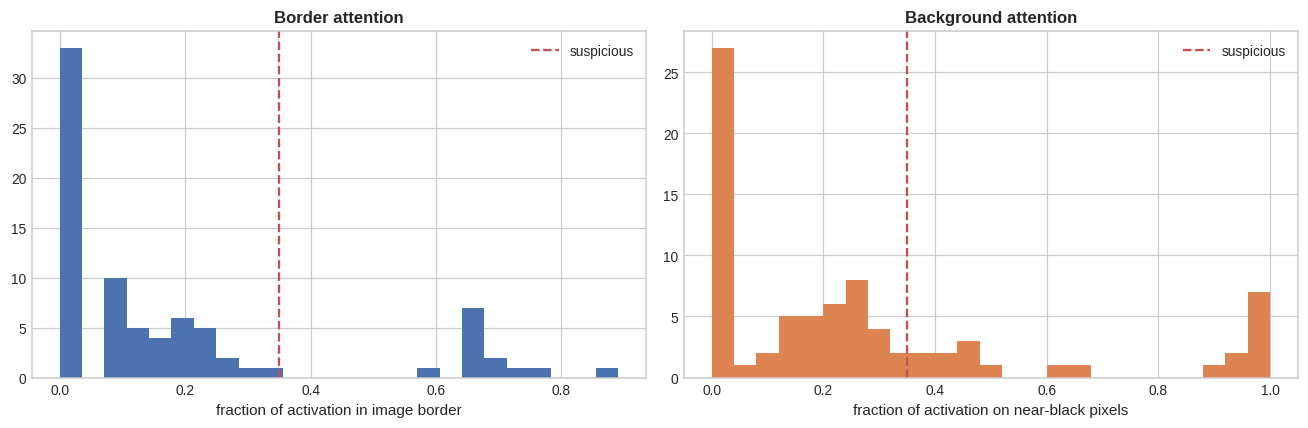

In [19]:
suspicious = attention[attention["suspicious_border"] | attention.get("suspicious_background", False)]
print(f"{len(suspicious)} of {len(attention)} heatmaps "
      f"({100 * len(suspicious) / max(len(attention), 1):.1f}%) concentrate on borders or "
      "background rather than tissue.")
print()
if len(suspicious) / max(len(attention), 1) > 0.3:
    print("WARNING: a large fraction of attention sits off-tissue. Before trusting any metric,")
    print("check the preprocessing - padding, resize artefacts or burnt-in text on the scans.")
else:
    print("Most attention falls on tissue rather than image margins, which is the expected and")
    print("reassuring outcome.")

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(attention["border_mass"], bins=25, color="#4C72B0")
axes[0].axvline(0.35, color="#C44E52", ls="--", label="suspicious")
axes[0].set_xlabel("fraction of activation in image border")
axes[0].set_title("Border attention")
axes[0].legend()
if "background_mass" in attention:
    axes[1].hist(attention["background_mass"].dropna(), bins=25, color="#DD8452")
    axes[1].axvline(0.35, color="#C44E52", ls="--", label="suspicious")
    axes[1].set_xlabel("fraction of activation on near-black pixels")
    axes[1].set_title("Background attention")
    axes[1].legend()
figure.tight_layout()
show(figure, "02_attention_sanity")

---
## 4. Outcome gallery

True positives are the least informative panel. The false positives and false negatives are where
the model's failure modes live.

In [20]:
LABEL = "irf"
label_index = label_names.index(LABEL)

probabilities = result.test["probabilities"][:, label_index]
truth = result.test["targets"][:, label_index]
predicted = (probabilities >= thresholds[label_index]).astype(int)

categories = {
    "true positive": np.flatnonzero((predicted == 1) & (truth == 1)),
    "false positive": np.flatnonzero((predicted == 1) & (truth == 0)),
    "false negative": np.flatnonzero((predicted == 0) & (truth == 1)),
    "true negative": np.flatnonzero((predicted == 0) & (truth == 0)),
}
for name, indices in categories.items():
    print(f"{name:16s}: {len(indices):4d} scans")

true positive   :  603 scans
false positive  :   19 scans
false negative  :  108 scans
true negative   :  642 scans


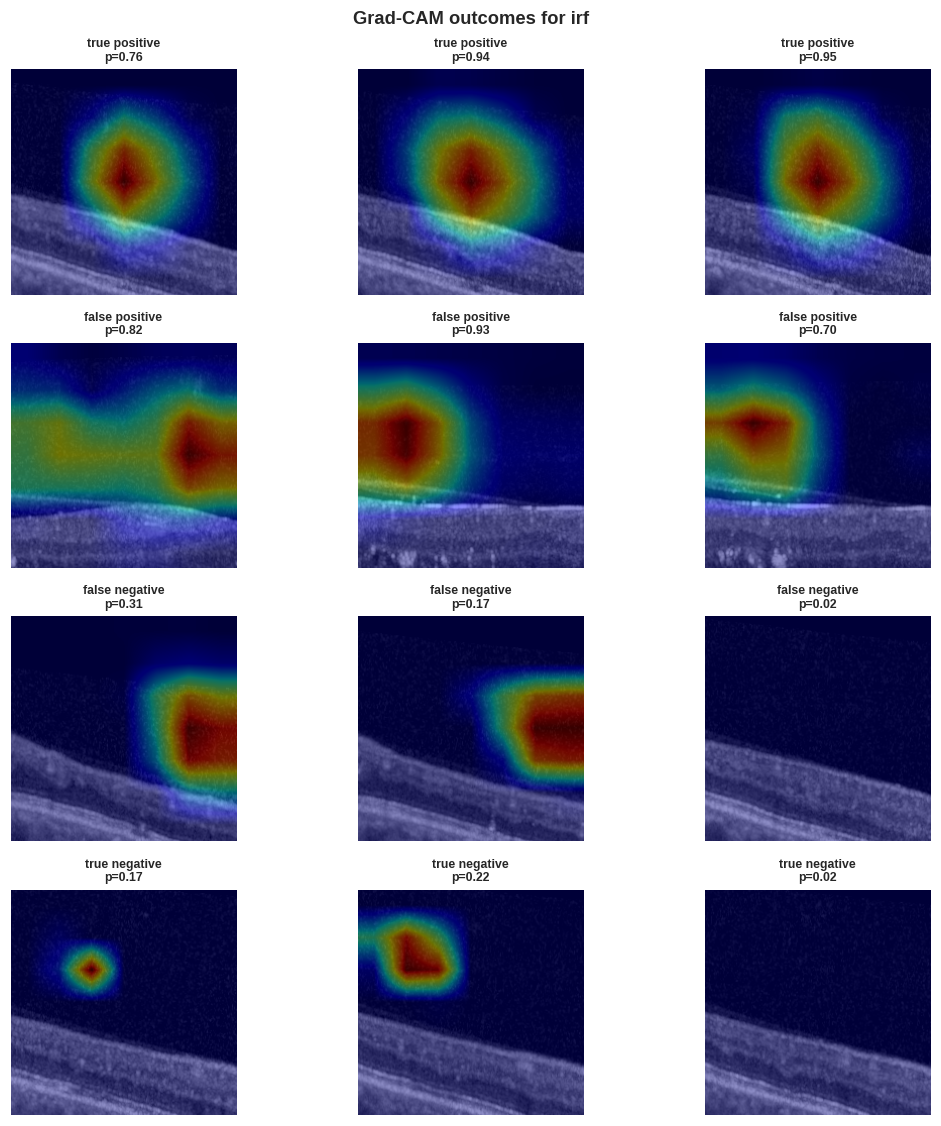

In [21]:
panels = {}
for name, indices in categories.items():
    chosen = indices[:3]
    entries = []
    for scan_index in chosen:
        raw_i, cams_i, _ = explain(int(scan_index), labels=[LABEL])
        entries.append({
            "image": raw_i,
            "heatmap": cams_i[0].heatmap,
            "probability": cams_i[0].probability,
        })
    panels[name] = entries

show(plotter.outcome_gallery(panels, label=LABEL, n_cols=3), f"03_outcomes_{LABEL}")

---
## 5. Patient-level confidence intervals

The headline numbers, with the uncertainty that comes from having 87 patients rather than 9,396
independent scans.

Resampling scans would treat 49 slices of one volume as 49 independent observations and produce
intervals several times too narrow.

In [22]:
RUN_BOOTSTRAP = True
N_BOOTSTRAP = 1000 if pipeline.env.device == "cuda" else 400

bootstrap_frames = []
if RUN_BOOTSTRAP:
    for run in all_results:
        evaluator = RunEvaluator(run, model=None, data=None, device="cpu", seed=42)
        try:
            evaluator.calibrate()
        except Exception:
            pass   # calibration is optional here; the bootstrap works on raw probabilities too
        table = evaluator.bootstrap(n_iterations=N_BOOTSTRAP, use_calibrated=evaluator.scaler is not None)
        table.insert(1, "model", run.model_name)
        bootstrap_frames.append(table)
    bootstrap = pd.concat(bootstrap_frames, ignore_index=True)
else:
    bootstrap = ResultsAggregator(all_results).collect_bootstrap()

bootstrap[["model", "metric", "point_estimate", "ci_lower", "ci_upper", "n_patients"]]

20:13:20 | WARNING | olives.calibration | label 'atrophy_thinning' is single-class in the calibration fold; temperature fixed at 1.0
20:13:20 | WARNING | olives.calibration | label 'vmt' is single-class in the calibration fold; temperature fixed at 1.0
20:13:21 | WARNING | olives.calibration | label 'rpe_disruption' is single-class in the calibration fold; temperature fixed at 1.0
20:13:21 | WARNING | olives.calibration | label 'ped_serous' is single-class in the calibration fold; temperature fixed at 1.0
20:13:21 | INFO    | olives.calibration | fitted temperatures on 882 calibration rows: [1.0, 1.303, 1.967, 1.464, 1.321, 3.889, 3.202, 3.207, 2.15, 1.0, 1.155, 1.42, 1.14, 1.0, 1.0, 0.797]
20:15:26 | INFO    | olives.bootstrap |   macro_f1       0.5004 [0.4590, 0.5795]
20:17:32 | INFO    | olives.bootstrap |   macro_auroc    0.8505 [0.7948, 0.8905]
20:19:37 | INFO    | olives.bootstrap |   macro_auprc    0.5476 [0.5120, 0.6584]


,model,metric,point_estimate,ci_lower,ci_upper,n_patients
0,oct_only,macro_f1,0.5004,0.4590,0.5795,13
1,oct_only,macro_auroc,0.8505,0.7948,0.8905,13
2,oct_only,macro_auprc,0.5476,0.5120,0.6584,13


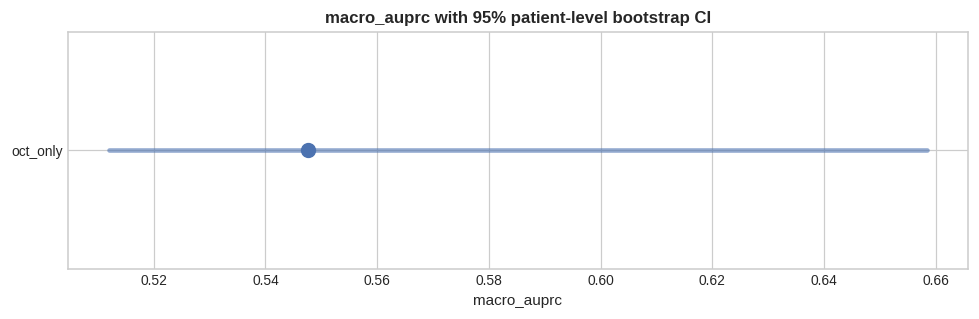

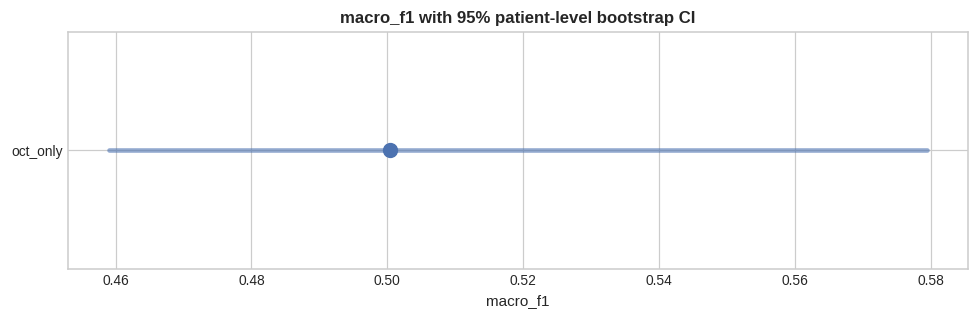

In [23]:
show(plotter.bootstrap_intervals(bootstrap, metric="macro_auprc"), "04_bootstrap_auprc")
show(plotter.bootstrap_intervals(bootstrap, metric="macro_f1"), "05_bootstrap_f1")

In [24]:
# The question every comparison reduces to: do the intervals actually separate?
aggregator = ResultsAggregator(all_results)
for metric in ["macro_auprc", "macro_f1", "macro_auroc"]:
    overlap = aggregator.intervals_overlap(metric)
    if overlap.empty:
        continue
    print(f"\n=== {metric} ===")
    display(overlap[["model_a", "model_b", "a", "b", "difference", "conclusion"]])

**How to read that table.** `no supported difference` means the two models' intervals overlap, so
the data does not support a claim that one beats the other — regardless of which point estimate is
higher. With ~13 test patients, only large effects will separate, and saying so plainly is more
useful than a hedged claim of superiority.

### The overlap check is descriptive, not a test

The table above compares two **independently** computed intervals. Most of the width of each one
comes from patient difficulty - some patients are simply harder - and that component is *shared* by
both models, so it cancels when the difference itself is resampled. Overlapping intervals therefore
routinely conceal a difference that holds in every resample.

`paired_difference` draws patients with replacement once and scores **both** arms on that same draw.
It is the test that should decide any model comparison in this project; `intervals_overlap` is kept
only for the descriptive table.

In [ ]:
# Paired patient-level difference: the test that actually decides the comparison.
REFERENCE = "oct_only"          # or "oct_improved" once that arm exists
CONTENDER = "gated_fusion"      # or "fusion_longitudinal"

models = sorted({r.model_name for r in all_results})
if REFERENCE in models and CONTENDER in models:
    paired = aggregator.paired_difference(CONTENDER, REFERENCE, seed=42)
    display(paired[["metric", "estimate_a", "estimate_b", "difference",
                    "ci_lower", "ci_upper", "p_two_sided", "conclusion"]].round(4))
else:
    print(f"need both {CONTENDER!r} and {REFERENCE!r} in all_results; have {models}")

In [ ]:
# Per-biomarker, split into confirmatory and exploratory. A macro average over
# thirteen labels dilutes an effect confined to one of them by a factor of thirteen,
# which is how a real result becomes invisible.
PREREGISTERED = ["ir_hemorrhages"]   # from scripts/preregister_targets.py --folds

if REFERENCE in models and CONTENDER in models:
    per_label = aggregator.paired_per_label(
        CONTENDER, REFERENCE, seed=42, preregistered=PREREGISTERED
    )
    display(per_label[["label", "role", "n_positive", "estimate_a", "estimate_b",
                       "difference", "ci_lower", "ci_upper", "p_two_sided"]].round(4))

**Reading it.** The `confirmatory` rows are the hypothesis test: those labels were named in advance
from training patients only, before any test data was touched. The `exploratory` rows are a fishing
expedition and must be labelled as one - with thirteen labels and a 95% interval, roughly one
apparent win is expected by chance.

If a control arm (`control_within_shuffle`, `control_quantise`, ...) is present, compare its
difference against the same reference. **A control that retains most of the gain has not been
passed:** it means the thing it destroys was not what the fusion arm was using.

---
## 6. Final report

In [25]:
import subprocess

completed = subprocess.run(
    [sys.executable, str(REPO_ROOT / "scripts" / "generate_report.py"),
     "--experiment-dir", str(RUNS_DIR),
     "--output", str(REPO_ROOT / "outputs" / "reports" / f"results_{BUDGET}.md")],
    capture_output=True, text=True, cwd=str(REPO_ROOT),
)
print(completed.stdout[-3000:])
if completed.returncode:
    print(completed.stderr[-2000:])

.2383 | False        |
| irhrf             |          973 |        0.27 |   0.8897 |   0.9543 |   0.8784 | False        |
| pavf              |          278 |        0.22 |   0.8152 |   0.6684 |   0.5848 | False        |
| favf              |          873 |        0.18 |   0.7269 |   0.7835 |   0.824  | False        |
| preretinal_tissue |          145 |        0.02 |   0.6707 |   0.185  |   0.2513 | False        |
| vitreous_debris   |          480 |        0.14 |   0.8009 |   0.7292 |   0.635  | False        |
| vmt               |            0 |        0.5  | nan      | nan      | nan      | True         |
| drt_me            |          514 |        0.4  |   0.9784 |   0.9706 |   0.8962 | False        |
| irf               |          711 |        0.59 |   0.9694 |   0.9765 |   0.9047 | False        |
| srf               |           51 |        0.74 |   0.984  |   0.8061 |   0.8081 | False        |
| rpe_disruption    |            1 |        0.5  |   0.9796 |   0.0345 |   0      | Fa

In [26]:
# Everything needed for the write-up, in one place.
summary = aggregator.comparison(sort_by="macro_auprc")
summary.to_csv(REPO_ROOT / "outputs" / "reports" / f"comparison_{BUDGET}.csv", index=False)
bootstrap.to_csv(REPO_ROOT / "outputs" / "reports" / f"bootstrap_{BUDGET}.csv", index=False)
aggregator.per_label_pivot("auprc").to_csv(
    REPO_ROOT / "outputs" / "reports" / f"per_label_auprc_{BUDGET}.csv"
)

print("written to outputs/reports/:")
for path in sorted((REPO_ROOT / "outputs" / "reports").glob("*")):
    print(f"  {path.name}")

written to outputs/reports/:
  bootstrap_colab_gpu.csv
  comparison_colab_gpu.csv
  per_label_auprc_colab_gpu.csv
  results_colab_gpu.md


---
## 7. Conclusions

### What the evidence supports

Fill these in from the tables above. Every claim needs a model, a split, a seed/fold, a target
set and an interval — a bare number is not a result.

### What it does not support

- **No diagnostic or deployment claim.** One U.S. clinic, no untreated control group, 87
  patients. The dataset's own authors flag the geographic and cohort limitations.
- **No causal claim.** Biomarkers here are retrospectively graded indicators; the OLIVES authors
  state explicitly that they are *not causal* to disease. Grad-CAM shows attention, not reasoning.
- **No claim about rare biomarkers.** Several labels have zero positives in the test partition.
  Their metrics are undefined and are reported as such.

### Structural limits worth stating in the write-up

1. **87 patients.** The effective sample size is the patient count, not the scan count. Intervals
   are wide and will stay wide.
2. **One CST and one BCVA per visit**, shared across all 49 B-scans, while biomarkers vary slice
   to slice. Clinical features can shift a scan's prior but cannot explain within-volume
   variation — a ceiling on any fusion result, identified in the EDA before modelling began.
3. **Treatment-induced domain shift** between first and last visit, which is also the only pair
   of visits carrying biomarker labels.
4. **Labels are modelled independently** though several are near mutually exclusive (PAVF/FAVF).
5. **Single data source**, so nothing here speaks to generalisation across sites or equipment.

### Honest outcomes

A rigorous negative result — clinical fusion failing to beat a well-controlled OCT baseline — is
a legitimate finding, and this pipeline was built so that outcome would be believable: fixed
splits, frozen thresholds, patient-level intervals, and a mechanism check on the gate itself.

### Reproducing everything

```bash
python scripts/audit_data.py     --config configs/data.yaml
python scripts/make_splits.py    --config configs/data.yaml --folds
python scripts/run_comparison.py --budget colab_gpu --seeds 42 43 44 --evaluate
python scripts/generate_report.py --experiment-dir outputs/runs/colab_gpu
```

### Remaining work

- Five-fold patient-grouped cross-validation for the final numbers (`--folds` is already written).
- Self-supervised pretraining on the unlabelled OCT pool (Phase 6).
- Fundus and volume-level modelling — **blocked**: not present in this data mirror.